QUESTÃO I:<br>

Professor, eu tive resultados, bem limitados, mas consegui ofuscar o background de certa forma. Porém eu percebi que talvez minhas imagens, minhas fotos não estejam propícias a visualização em profudindade, não sei. O efeito me pareceu bem discreto, talvez pelas paredes brancas, falta de ângulo (testei todas com uma leve diferença horizontal apenas). Depois não consegui ajustar muito bem, tive alguns problemas com many requests, nesta questão específica, mas está plotando a saída.

Aqui fiz um disparity, apliquei alguns filtros pra tentar reduzir ruído e pegar melhor as depths, mas aparentemente nada muito bem contrastado ou definido. Pelos plots de profudindade aparenemente o algoritmo ficou bem confuso entre o que estava na frente ou atrás, e eu imagino que seja por conta da palleta ou textura de background da foto.

In [39]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
import urllib
import requests
import ssl
import random
import time

ssl._create_default_https_context = ssl._create_unverified_context

In [40]:
def load_image_from_url(url, max_retries=3):
    """Load image with retry logic for rate limiting"""
    for retry in range(max_retries):
        try:
            with urllib.request.urlopen(url) as response:
                img_array = np.asarray(bytearray(response.read()), dtype=np.uint8)
                return cv.imdecode(img_array, cv.IMREAD_COLOR)
        except Exception as e:
            if "429" in str(e):
                # Exponential backoff with jitter
                wait_time = (2 ** retry) + random.random()
                print(f"Rate limited. Waiting {wait_time:.2f}s before retry {retry+1}/{max_retries}")
                time.sleep(wait_time)
                continue
            else:
                print(f"Error for URL {url}: {e}")
                return None
    
    print(f"Failed to load image after {max_retries} retries: {url}")
    return None

image_urls = [
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/q1/1.jpg",
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/q1/2.jpg",
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/q1/3.jpg",
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/q1/4.jpg",
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/q1/5.jpg",
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/q1/6.jpg"
]

In [41]:
def foreground_background(left_url, right_url, numDisparities=64, blockSize=5, threshold=110):
    left_img = load_image_from_url(left_url)
    right_img = load_image_from_url(right_url)

    if left_img is None:
        print(f"Failed to load left image from {left_url}")
        return None, None, None, None
        
    if right_img is None:
        print(f"Failed to load right image from {right_url}")
        return None, None, None, None


    gray_left = cv.cvtColor(left_img, cv.COLOR_BGR2GRAY)
    gray_right = cv.cvtColor(right_img, cv.COLOR_BGR2GRAY)

    # StereoBM e Params.
    stereo = cv.StereoBM.create(numDisparities=numDisparities, blockSize=blockSize)
    stereo.setTextureThreshold(20)
    stereo.setUniquenessRatio(15)
    stereo.setSpeckleRange(16)
    # stereo.setSpeckleWindowSize(100)
    stereo.setDisp12MaxDiff(25)
    
    # computa e normaliza disparity
    disparity = stereo.compute(gray_left, gray_right)
    disparity_visual = cv.normalize(disparity, None, alpha=0, beta=255, norm_type=cv.NORM_MINMAX, dtype=cv.CV_8U)
    _, fg_mask = cv.threshold(disparity_visual, threshold, 255, cv.THRESH_BINARY)
    
    # Morfologia para remover ruído / separa foreground background
    kernel = np.ones((5, 5), np.uint8)
    fg_mask = cv.morphologyEx(fg_mask, cv.MORPH_CLOSE, kernel)
    fg_mask = cv.morphologyEx(fg_mask, cv.MORPH_OPEN, kernel)
    blurred = cv.GaussianBlur(left_img, (25, 25), 0)
    foreground = cv.bitwise_and(left_img, left_img, mask=fg_mask)
    bg_mask = cv.bitwise_not(fg_mask)
    background = cv.bitwise_and(blurred, blurred, mask=bg_mask)
    
    result = cv.add(foreground, background)
    
    return left_img, disparity_visual, fg_mask, result

Processando par 1-2...


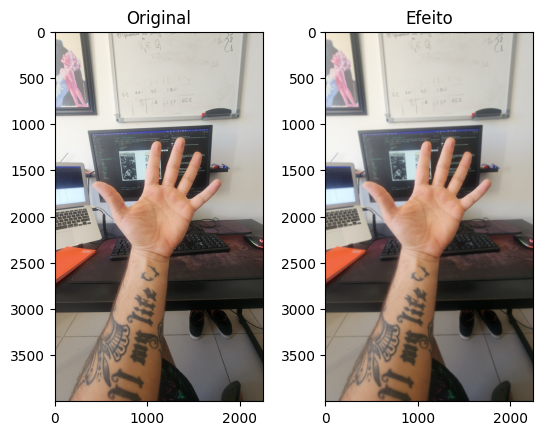

Processando par 3-4...


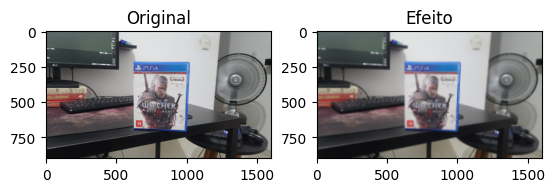

Processando par 5-6...


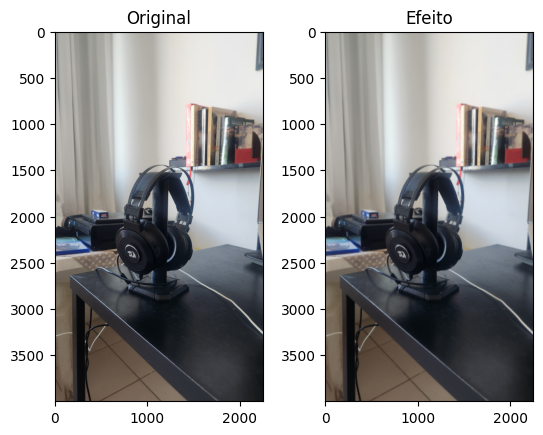

In [42]:
def process_pair():
    pairs = []
    for i in range(0, len(image_urls), 2):
        if i+1 < len(image_urls):
            left_url = image_urls[i]
            right_url = image_urls[i+1]
            left_name = left_url.split('/')[-1].split('.')[0]
            right_name = right_url.split('/')[-1].split('.')[0]
            pairs.append({
                'name': f"{left_name}-{right_name}",
                'left_url': left_url,
                'right_url': right_url
            })
    
    # Params pra cada par
    params = [
        {'numDisparities': 128, 'blockSize': 15, 'threshold': 50},  # par 1
        {'numDisparities': 96, 'blockSize': 11, 'threshold': 80},   # par 2
        {'numDisparities': 64, 'blockSize': 13, 'threshold': 60}    # par 3
    ]

    for i, pair in enumerate(pairs):
        print(f"Processando par {pair['name']}...")
        original, disparity, mask, portrait = foreground_background(
            pair['left_url'],
            pair['right_url'],
            **params[i]
        )

        if original is None or disparity is None or mask is None or portrait is None:
            print(f"Par {pair['name']} pulado por erro de carregamento.")
            continue

        # Configuração nativa do matplotlib
        plt.figure()
        
        plt.subplot(1, 2, 1)
        plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
        plt.title('Original')
        
        plt.subplot(1, 2, 2)
        plt.imshow(cv.cvtColor(portrait, cv.COLOR_BGR2RGB))
        plt.title('Efeito')
        
        plt.show()

process_pair()